In [1]:
import numpy as np
import scipy as sp
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
from matplotlib import transforms
import datetime
import seaborn as sns
from nilearn import signal, plotting, image, masking
import itertools
import functools
import nibabel as nib
import json
import colorcet
from dataclasses import dataclass
from pathlib import Path
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

import sys
# sys.path.append('/RAID1/jupytertmp/quantification')
sys.path.append('/RAID1/jupytertmp/quantification/src')
import blood

sns.set_theme(style='ticks')
# plt.style.use('dark_background')

%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

In [2]:
ROOT = Path('/RAID1/jupytertmp/quantification')

In [3]:
# subjects = [8, 9, 10, 11, 12, 15, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28]
# subjects = [8, 11, 12, 21, 22, 24, 26, 27] # work out of the box 
# subjects = [10, 15, 18, 19] # don't have distinguishable peak
# subjects = [28] # did not have injection end time

subjects = [8, 9, 10, 11, 12, 15, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28]
# subjects = [12]

In [4]:
participants = pd.read_csv(ROOT / 'participants.tsv', sep='\t')

participants = participants.assign(
    start_time = participants.apply(lambda row: datetime.time(row['H_START'], row['M_START'], row['S_START']), axis=1),
    end_time = participants.apply(lambda row: datetime.time(row['H_FINISH'], row['M_FINISH'], row['S_FINISH']), axis=1)
)

# Fix the no injection stop time issue with subject 28 - add 1 hour 10 minutes to the start
start, = participants.loc[participants['sess_id'] == 'fp028-petmri', 'start_time'].values
end = datetime.datetime.combine(datetime.date(2023, 4, 23), start) + datetime.timedelta(hours=1, minutes=10)
end = end.time()
participants.loc[participants['sess_id'] == 'fp028-petmri', 'end_time'] = end

# Addd glucose values for subject 23
glucose = np.mean([93, 86]) / 18
participants.loc[participants['sess_id'] == 'fp023-petmri', 'blood sugar (avg before & after)/18'] = glucose

# Same for subject 17 - use average for now 
glucose = 96 / 18
participants.loc[participants['sess_id'] == 'fp017-petmri', 'blood sugar (avg before & after)/18'] = glucose

In [5]:
@dataclass
class CONST:

    calibration:    float = 506 # mL^-1, obtained manually for each scanner
    # calibration_adj: float = 1.849673202614379 # adjustment factor to the calibration factor for subjects after 23 
    calibration_adj: float = 1.908791208791209 # adjustment factor to the calibration factor for subjects after 23 
    calibration_adj_sub012: float = 1.315909090909091 # subject 12 is early, but an outlier. adjust the calibration by this factor, but this is questionable
    gm_density:     float = 1045 * 1000 / 1e6 # g/mL, from https://itis.swiss/virtual-population/tissue-properties/database/density/
    wm_density:     float = 1041 * 1000 / 1e6 # g/mL
    LC:             float = 0.65 # Wu (2003) Molecular Imaging & Biology
    # LC:             float = 0.89 # no unit, Graham (2002) Joural of Nuclear Medicine
    VB:             float = 0.052 # %, fractional blood volume. Muzi (2009) Journal of Nuclear Medicine 

    # Solutions from Feng 1993
    A1, l1, A2, l2, A3, l3 = 767.3, -4.195, 27.43, -0.232, 29.13, -0.0165
    A1_sd, l1_sd, A2_sd, l2_sd, A3_sd, l3_sd = 360, 1.38, 7.48, 0.112, 5.22, 0.0076
    tau:            float = 0.905

    # RBC to plasma ratio for FDG - solutions from Phelps (1979)
    B:              float = 0.8 # y-axis intercept - no unit (?)
    K:              float = 0.0012 # slope of the line - min^-1

    tstar: int = 5 # min
    task_delay: int = 2 # min

---

# Get the data

In [ ]:
DATA = {subject: {} for subject in subjects}

In [ ]:
for subject, data in DATA.items():

    subroot = ROOT / f'sub-{subject:03}'

    # Arterial input 
    filename = subroot / f'fp{subject:03}.crv'
    aif = pd.read_csv(filename, header=None, sep=r'\s+', names=['y', 'mo', 'd', 'h', 'm', 's', 'counts'], usecols=range(7))
    aif.index = aif.apply(lambda row: datetime.datetime(2021, 4, 21, int(row.h), int(row.m), int(row.s)), axis=1)
    data['aif'] = aif

    # PET time series
    # filename = subroot / 'pet' / f'sub-fp{subject:03}_rec-45sfrscanner_acq-all_pet_trimmed_mcf_filt-6min_fwhm-6mm.nii.gz'
    filename = subroot / 'PREPROC' / f'sub-fp{subject:03}_rec-45sfrscanner_acq-all_pet-trimmed-mc-filt-smooth.nii.gz'
    data['pet'] = filename
    assert filename.exists()

    # Sidecar
    sidecar = subroot / 'pet' / f'sub-fp{subject:03}_rec-45sfrscanner_acq-all_pet.json'
    with open(sidecar) as f:
        metadata = json.load(f)
    data['sidecar'] = metadata

    # IMPORTANT: there are 89 time frames in the trimmed (preprocessed) pet file, but still 94 in the sidecar
    # Remove the last frames from the sidecar file right away 
    nvols = nib.load(data['pet']).shape[-1]
    data['sidecar']['FrameReferenceTime'] = data['sidecar']['FrameReferenceTime'][:nvols]
    data['sidecar']['FrameDuration'] = data['sidecar']['FrameDuration'][:nvols]

    # T1 in pet space
    filename = subroot / 'PREPROC' / f'pet2anat_InverseWarped.nii.gz'
    data['anat'] = filename
    assert filename.exists()

    # GM mask
    filename = subroot / 'PREPROC' / f'mask_gm-pet.nii.gz'
    data['gm_mask'] = filename
    assert filename.exists()

    # GM probability in pet space 
    filename = subroot / 'PREPROC' / f'prob_gm-pet.nii.gz'
    data['gm_probseg'] = filename
    assert filename.exists()

    # V1 mask
    filename = subroot / 'PREPROC' / f'mask_v1-pet.nii.gz'
    data['v1_mask'] = filename

    # SM1 mask for control analysses
    filename = subroot / 'PREPROC' / f'mask_sm1-pet.nii.gz'
    data['sm1_mask'] = filename
    assert filename.exists()

    # Head mask
    filename = subroot / 'PREPROC' / f'sub-fp{subject:03}_rec-45sfrscanner_acq-all_pet-trimmed-mc-sum-headmask.nii.gz'
    data['head_mask'] = filename
    assert filename.exists()

    # Brain mask
    filename = subroot / 'PREPROC' / f'sub-fp{subject:03}_rec-45sfrscanner_acq-all_pet-trimmed-mc-sum-brainmask.nii.gz'
    data['brain_mask'] = filename
    assert filename.exists()

    # Mask with every gm voxel except in occipital cortex
    filename = subroot / 'PREPROC' / f'mask_gm-nooccipital-pet.nii.gz'
    data['gm_mask_edited'] = filename
    assert filename.exists()

    # Checker and rests onsets
    checker_onsets = subroot / 'glm' / f'sub-fp{subject:03}_checker_onset.txt'
    data['checker_onsets_file'] = checker_onsets

    # Blood values and injection start/end
    hematocrit, glucose, injection_start, injection_end = participants.loc[participants.sess_id == f'fp{subject:03}-petmri', ['hematocrit', 'blood sugar (avg before & after)/18', 'start_time', 'end_time']].to_numpy()[0]
    glucose = float(glucose) # mM/L
    data['hematocrit'] = hematocrit
    data['glucose'] = glucose
    data['injection_start'] = datetime.datetime.combine(datetime.date(2021, 4, 21), injection_start)
    data['injection_end'] = datetime.datetime.combine(datetime.date(2021, 4, 21), injection_end)

In [ ]:
# check that the injection srart time stamp matches the acquisition time in pet sidecar
assert datetime.datetime.strptime(data['sidecar']['AcquisitionTime'], '%H:%M:%S.%f').time() == injection_start

---

# Blood 

## Find blood delay and background radiation

- blood delay = delay between injection start time and radiation peak detection in aif. This is modelled by the tau parameter in Feng function
- background radiation = mode of values before injection start time 

In [ ]:
for subject, data in DATA.items():

    if subject in [15, 25]:
        continue

    print(subject, end='\r')

    aif = data['aif']
    injection_start = data['injection_start']
    injection_end = data['injection_end']

    blood_tac = aif.loc[ (injection_start <= aif.index) & (aif.index <= injection_end), 'counts']
    blood_tac = np.array(blood_tac, dtype=np.float64) # Bq
    sigma = np.sqrt(blood_tac)
    background, = aif.loc[aif.index < injection_start, 'counts'].mode() # Bq
    time_min = np.linspace(0, (blood_tac.size - 1)/60, blood_tac.size) # min

    filtered = sp.signal.savgol_filter(blood_tac, window_length=30, polyorder=3)
    peaks, _ = sp.signal.find_peaks(filtered, height=np.quantile(filtered, 0.9))
    blood_delay = (peaks[0] - 20) / 60 # min

    data['blood_tac'] = blood_tac
    data['sigma'] = sigma
    data['time'] = time_min
    data['background'] = background
    data['blood_tac_filtered'] = filtered
    data['first_peak'] = peaks[0]
    data['blood_delay'] = blood_delay

### Insert the average blood TAC for subjects 15 and 25

For these subjects the AIF files are corrupted. A lot of manual adjustments in the next two cells 

In [ ]:
minlens = [data['blood_tac'].size for subject, data in DATA.items() if subject in [23,24,26,27,28]]
minlen = min(minlens)

aifs = np.array([data['blood_tac'][:minlen] for subject, data in DATA.items() if subject in [23,24,26,27,28]])
aif_avg = aifs.mean(axis=0)

aif = DATA[25]['aif']
injection_start = DATA[25]['injection_start']
injection_end = DATA[25]['injection_end']

blood_tac = aif_avg ################ <<- the only change is here
blood_tac = np.array(blood_tac, dtype=np.float64) # Bq
sigma = np.sqrt(blood_tac)
background, = aif.loc[aif.index < injection_start, 'counts'].mode() # Bq
time_min = np.linspace(0, (blood_tac.size - 1)/60, blood_tac.size) # min

filtered = sp.signal.savgol_filter(blood_tac, window_length=30, polyorder=3)
peaks, _ = sp.signal.find_peaks(filtered, height=np.quantile(filtered, 0.9))
blood_delay = (peaks[0] - 20) / 60 # min

DATA[25]['blood_tac'] = blood_tac
DATA[25]['sigma'] = sigma
DATA[25]['time'] = time_min
DATA[25]['background'] = background
DATA[25]['blood_tac_filtered'] = filtered
DATA[25]['first_peak'] = peaks[0]
DATA[25]['blood_delay'] = blood_delay

In [ ]:
minlens = [data['blood_tac'].size for subject, data in DATA.items() if subject in [8,9,10,11,12,18,19]]
minlen = min(minlens)

aifs = np.array([data['blood_tac'][:minlen] for subject, data in DATA.items() if subject in [8,9,10,11,12,18,19]])
aif_avg = aifs.mean(axis=0)

blood_tac = aif_avg ################ <<- the only change is here
blood_tac = np.array(blood_tac, dtype=np.float64) # Bq
sigma = np.sqrt(blood_tac)
time_min = np.linspace(0, (blood_tac.size - 1)/60, blood_tac.size) # min

filtered = sp.signal.savgol_filter(blood_tac, window_length=30, polyorder=3)
peaks, _ = sp.signal.find_peaks(filtered, height=np.quantile(filtered, 0.9))
blood_delay = (peaks[0] - 20) / 60 # min

background = int(blood_tac[:(peaks[0]-20)].mean()) # Bq

DATA[15]['blood_tac'] = blood_tac
DATA[15]['sigma'] = sigma
DATA[15]['time'] = time_min
DATA[15]['background'] = background
DATA[15]['blood_tac_filtered'] = filtered
DATA[15]['first_peak'] = peaks[0]
DATA[15]['blood_delay'] = blood_delay
    

### Fine adjestments 

In [ ]:
fig, axs = plt.subplots(6, 2, figsize=(8,15), constrained_layout=True, sharex=True) 
for ax, subject in zip(axs, [8, 9, 12, 25, 27, 28]):

    x = np.linspace(0, 600/60, 600)
    y = DATA[subject]['blood_tac'][:600]

    ax[0].plot(x, y, 'k.')
    ax[0].plot(x, DATA[subject]['feng_function'](x), color='crimson')
    ax[0].set(title=f'sub-{subject:03} whole blood')

    ax[1].plot(x, DATA[subject]['feng_plasma_function'](x), color='crimson')
    ax[1].set(title=f'sub-{subject:03} blood plasma')

axs_left = axs.flatten()[::2]
for ax in axs_left:
    ax.set(ylim=(0,150))
    # ax.sharey(axs_left[0])

axs_right = axs.flatten()[1::2]
for ax in axs_right[1:]:
    ax.sharey(axs_right[0])

In [ ]:
for subject, data in DATA.items():

    if subject == 9:
        data['first_peak'] = np.nan
        data['blood_delay'] = 288 / 60
    elif subject == 10:
        data['first_peak'] = np.nan
        data['blood_delay'] = (97-10) / 60
    elif subject == 18:
        data['first_peak'] = np.nan
        data['blood_delay'] = 166 / 60
    elif subject == 19:
        data['first_peak'] = np.nan
        data['blood_delay'] = (89+20) / 60
    elif subject == 25:
        data['blood_delay'] -= (15/60)
    elif subject in [23, 12]:
        data['blood_delay'] += 3/60

## Fit Feng (1993) function

In thw code below, **feng_fit**, **p2b_fit** and **feng_plasma_fit** are FUNCTIONS that take time (min) as input

In [ ]:
# Initial guess are the solutions from the Feng paper
p0 = [CONST.A1, CONST.l1, CONST.A2, CONST.l2, CONST.A3, CONST.l3]

for subject, data in DATA.items():

    print(subject, end='\r')

    ydata = data['blood_tac']
    xdata = data['time']
    blood_delay = data['blood_delay']
    background = data['background']
    sigma = data['sigma']
    hematocrit = data['hematocrit']

    if subject in [15,25]:
        maxfev = 10000
    else:
        maxfev = 2500

    f = functools.partial(blood.feng, tau=blood_delay, background=background)
    popt, pcov = sp.optimize.curve_fit(
        f, xdata, ydata,
        p0=p0,
        sigma=sigma,
        absolute_sigma=True,
        full_output=False,
        maxfev=maxfev
    )

    A1, l1, A2, l2, A3, l3 = popt

    # For subjects before 23, use the actual calibration factor. For others, adjust
    if subject == 12:
        calibration = CONST.calibration * CONST.calibration_adj_sub012
    elif subject < 23:
        calibration = CONST.calibration
    else:
        calibration = CONST.calibration * CONST.calibration_adj

    feng_fit = functools.partial(
        blood.feng, 
        A1=A1, l1=l1, A2=A2, l2=l2, A3=A3, l3=l3, 
        tau=blood_delay,
        background=background
        )

    rbc2p_fit = functools.partial(
        blood.rbc_to_plasma_ratio,
        B=CONST.B,
        K=CONST.K
    )

    # Estimate plasma-to-blood ratio
    p2b_fit = functools.partial(
        blood.plasma_to_blood_ratio, 
        hematocrit=hematocrit, 
        rbc2p_fit=rbc2p_fit
        )

    # Convert to plasma radioactivity and adjust for the background. This is the final function we will use for integration in the Patlak plot
    # returns data in Bq/mL becasue of the *calibration*
    feng_plasma_fit = functools.partial(
        blood.feng_plasma, 
        feng_fit=feng_fit, 
        p2b_fit=p2b_fit, 
        background=background, 
        calibration=calibration,
        )

    # Get whole blood radioactivity in Bq/mL
    feng_whole_blood_fit = functools.partial(
        blood.feng_whole_blood,
        feng_fit=feng_fit,
        background=background,
        calibration=calibration,
    )

    feng_rbc_fit = functools.partial(
        blood.feng_rbc,
        feng_whole_blood_fit=feng_whole_blood_fit,
        feng_plasma_fit=feng_plasma_fit,
        hematocrit=hematocrit
    )


    data['feng_fit_popt'] = popt
    data['feng_fit_pcov'] = pcov

    data['feng_function'] = feng_fit
    data['feng_plasma_function'] = feng_plasma_fit
    data['feng_whole_blood_function'] = feng_whole_blood_fit
    data['feng_rbc_function'] = feng_rbc_fit
    data['p2b_function'] = p2b_fit
    data['rbc2p_function'] = rbc2p_fit


---

# PET

## Get the time stamps 

In [ ]:
for subject, data in DATA.items():

    frame_ref_time = np.array(data['sidecar']['FrameReferenceTime'])
    frame_duration = np.array(data['sidecar']['FrameDuration'])

    # timing of pet scan
    pet_timing = (
    pd.DataFrame(index=[data['injection_start'] + datetime.timedelta(seconds=sec) for sec in frame_ref_time])
    .assign(
        time = frame_ref_time / 60,
        frame_start = (np.cumsum(frame_duration) - frame_duration) / 60,
        frame_end = np.cumsum(frame_duration) / 60,
        frame_duration = frame_duration / 60,
        injection = lambda x: (data['injection_start'] <= x.index) & (x.index <= data['injection_end']),
        before_injection = lambda x: x.index <= data['injection_start'],
        after_injection = lambda x: x.index >= data['injection_end'],
        quantification = lambda x: (data['injection_start'] + datetime.timedelta(minutes=CONST.tstar) < x.index) & (data['injection_start'] <= x.index) & (x.index <= data['injection_end']),
        )
    )

    data['pet_timing'] = pet_timing


    # Timing of task presentation
    task_onsets = (
        pd.read_csv(data['checker_onsets_file'], sep=r'\s+', header=None, names=['checker_start', 'checker_duration', 'one'])
        .iloc[:, :-1] # remove the column of ones
        .assign(
            checker_stop = lambda x: x.checker_start + x.checker_duration,
            rest_start = lambda x: [int(x.checker_start[0] - x.checker_duration[0])] + x.checker_stop[:-1].tolist(),
            rest_stop = lambda x: x.checker_start #+ x.checker_duration
            )
        .drop('checker_duration', axis=1)
        .loc[:, ['rest_start', 'rest_stop', 'checker_start', 'checker_stop']]
        .apply(lambda x: [ data['injection_start'] + datetime.timedelta(seconds=s + CONST.task_delay*60) for s in x ]) # add two minutes to task onsets
    )

    task_timing = pd.DataFrame(dict(
            time = pet_timing.time,
            checker = [ np.where((task_onsets.checker_start <= time) & (time <= task_onsets.checker_stop))[0] for time in pet_timing.index ],
            rest = [ np.where((task_onsets.rest_start <= time) & (time <= task_onsets.rest_stop))[0] for time in pet_timing.index ],
        ),
        index=pet_timing.index
    )

    task_timing.checker = task_timing.checker.apply(lambda item: 0 if item.size == 0 else item[0]+1)
    task_timing.rest = task_timing.rest.apply(lambda item: 0 if item.size == 0 else item[0]+1)


    data['task_onsets'] = task_onsets
    data['task_timing'] = task_timing

In [ ]:
feng_plasma_fit(10)

In [ ]:
# for subject, data in DATA.items():

#     print(subject, end='\r')

#     feng_plasma_fit = data['feng_plasma_function']
#     pet_timing = data['pet_timing']

#     plasma_integral = np.array([ sp.integrate.quad(feng_plasma_fit, 0, ft)[0] for ft in pet_timing.time ])
#     data['plasma_integral'] = plasma_integral

# Save the data

In [ ]:
timestamp = datetime.datetime.strftime(datetime.datetime.now(), '%d-%B-%Y_%H-%M')
# filename = f'/RAID1/jupytertmp/quantification/DATA_{timestamp}.joblib'
filename = ROOT / 'DATA_12April2026-THESIS.joblib'

joblib.dump(DATA, filename)

In [6]:
DATA = joblib.load(ROOT / 'DATA_12April2026-THESIS.joblib')

In [12]:
DATA[12]['task_timing'].checker.to_numpy()

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2,
       2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 3, 3,
       3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0,
       0])

In [8]:
DATA[12]['pet_timing']

,time,frame_start,frame_end,frame_duration,injection,before_injection,after_injection,quantification
2021-04-21 10:20:35.491100,0.374852,0.00,0.75,0.75,True,False,False,False
2021-04-21 10:21:20.491100,1.124852,0.75,1.50,0.75,True,False,False,False
2021-04-21 10:22:05.491000,1.874850,1.50,2.25,0.75,True,False,False,False
2021-04-21 10:22:50.491000,2.624850,2.25,3.00,0.75,True,False,False,False
2021-04-21 10:23:35.491000,3.374850,3.00,3.75,0.75,True,False,False,False
...,...,...,...,...,...,...,...,...
2021-04-21 11:23:35.490000,63.374833,63.00,63.75,0.75,True,False,False,True
2021-04-21 11:24:20.490000,64.124833,63.75,64.50,0.75,True,False,False,True
2021-04-21 11:25:05.490000,64.874833,64.50,65.25,0.75,True,False,False,True
2021-04-21 11:25:50.490000,65.624833,65.25,66.00,0.75,True,False,False,True


# Global/task Ki and CMRGlc

[turkupet code for cmrglc](http://www.turkupetcentre.net/tpcclib-doc/v1/patlak_8c_source.html#:~:text=f%3D100.*Ca,621)

In [ ]:
cmrglc_dirname = 'QUANT/OUR-METHOD'

for subject, data in DATA.items():

    print(f'{subject = } - loading data...')
    subroot = ROOT / f'sub-{subject:03}'

    # create the output directory unless it already exists
    (subroot / cmrglc_dirname).mkdir(parents=True, exist_ok=True)

    pet = data['pet']
    mask = data['head_mask']
    plasma_integral = data['plasma_integral']
    feng_plasma_fit = data['feng_plasma_function']
    glucose = data['glucose']
    pet_timing = data['pet_timing']
    task_timing = data['task_timing']

    # Load the time series 
    timeseries = masking.apply_mask(pet, mask)

    # Patlack x and y. ignore dividion by zero errors
    feng_plasma = feng_plasma_fit(pet_timing.time.to_numpy())
    with np.errstate(divide='ignore', invalid='ignore'):
        x = ( plasma_integral / feng_plasma )[:, np.newaxis]
        y = timeseries / feng_plasma[:, np.newaxis]
    
    #################################################################################
    # Global Ki and CMRGlc - fitting on the whole time series, regardless of the task 
    print(f'\t{subject = } - calculating global cmrglc...')
    
    x_subset = x[pet_timing.quantification, :]
    y_subset = y[pet_timing.quantification, :]

    model = LinearRegression(positive=True, fit_intercept=False).fit(
        X=x_subset, 
        y=y_subset
    )
    V_B = model.intercept_
    Ki_voxel = model.coef_.flatten()
    cmrglc_voxel = Ki_voxel * 100 * glucose / (CONST.gm_density * CONST.LC)

    # Convert the arrays to images and save them
    for quantname, quant in zip(['Ki', 'cmrglc'], [Ki_voxel, cmrglc_voxel]):
        filename = subroot / cmrglc_dirname / f'sub-fp{subject:03}_quant-{quantname}_task-global.nii.gz'
        img = masking.unmask(quant, mask)
        img.to_filename(filename)
        data[f'{quantname}_task-global'] = filename

    ##########################################################################
    # Task Ki and CMRGlc - separate time series into checker/rest time periods
    for task in ['rest', 'checker']:
        for run in range(1,5):

            # Identify indices for patlak x and y for the run
            nframes = (task_timing[task] == run).sum()
            mid = (nframes+1) // 2
            cumsum = (task_timing[task] == run).cumsum()
            skip_two = cumsum > 2
            frames_mask = skip_two & (task_timing[task] == run) & pet_timing.quantification

            print(f'\t\t{subject = } - calculating cmrglc task {task} run {run}... selecting {frames_mask.sum()} out of {nframes} frames')

            # Patlak x and y
            x_subset = x[frames_mask, :]
            y_subset = y[frames_mask, :]

            model = LinearRegression(positive=True, fit_intercept=True).fit(X=x_subset, y=y_subset)
            V_B = model.intercept_
            Ki_voxel = model.coef_.flatten()
            cmrglc_voxel = Ki_voxel * 100 * glucose / (CONST.gm_density * CONST.LC)

            # rmse
            # model_explained = V_B + Ki_voxel * x_subset
            model_explained = model.predict(x_subset)
            rmse_voxel = root_mean_squared_error(y_pred=model_explained, y_true=y_subset, multioutput='raw_values')

            # r squared
            r2_voxel = r2_score(y_pred=model_explained, y_true=y_subset, multioutput='raw_values')

            for quant, array in zip(['Ki', 'cmrglc', 'rmse', 'r2'], [Ki_voxel, cmrglc_voxel, rmse_voxel, r2_voxel]):
                filename =  subroot / cmrglc_dirname / f'sub-fp{subject:03}_quant-{quant}_frames-skiptwo_task-{task}_run-{run}.nii.gz'
                img = masking.unmask(array, mask)
                img.to_filename(filename)
                data[f'{quant}_task-{task}_run-{run}'] = filename



        #################################################
        # Calulate averages across the runs for each task
        print(f'\t{subject = } - calculating cmrglc task {task} run average...')

        for quant in ['Ki', 'cmrglc', 'rmse', 'r2']:
            runs_filenames = [subroot / cmrglc_dirname / f'sub-fp{subject:03}_quant-{quant}_frames-skiptwo_task-{task}_run-{run}.nii.gz' for run in range(1,5)]
            avg_run = image.mean_img(runs_filenames, copy_header=True)
            filename = subroot / cmrglc_dirname / f'sub-fp{subject:03}_quant-{quant}_frames-skiptwo_task-{task}_run-average.nii.gz'
            avg_run.to_filename(filename)
            data[f'{quant}_task-{task}_run-average'] = filename

# GLM

In [ ]:
for subject, data in DATA.items():

    print(subject, end='\r')
    subroot = ROOT / f'sub-{subject:03}'

    pet = data['pet']
    pet_timing = data['pet_timing']
    task_timing = data['task_timing']

    baseline_mask = subroot / 'PREPROC' / f'mask_gm-nooccipital-pet.nii.gz'
    assert baseline_mask.exists(), f'{subject}'

    baseline = masking.apply_mask(pet, baseline_mask).mean(axis=1)

    nframes = pet_timing.shape[0]

    regressors = task_timing.assign(
        baseline_linear = np.arange(nframes) * pet_timing.frame_duration,
        baseline_quadratic = lambda x: x.baseline_linear ** 2 * pet_timing.frame_duration,
        baseline_cubic = lambda x: x.baseline_linear ** 3 * pet_timing.frame_duration,
        baseline = baseline,
        task = lambda x: (x.checker > 0).cumsum() * pet_timing.frame_duration, # multiply by frame duration in minutes to make the slope 1 min^-1
        task_simplified = lambda x: np.arange(nframes) * pet_timing.frame_duration,
    )

    Q, R = sp.linalg.qr(regressors.loc[:, ['baseline', 'task']], mode='economic')
    orth = Q @ np.diag(np.diag(R)) # take the diagonal of R and create a diagonal 2x2 matrix out of it
    regressors = regressors.assign(
        baseline_orth = orth[:, 0],
        task_orth = orth[:, 1]
    )

    assert np.isclose(regressors.baseline @ regressors.task_orth, 0)

    data['regressors'] = regressors

In [15]:
def r2bar(r2: np.ndarray, n: int, p: int):
    return 1 - (1 - r2) * (n-1) / (n-p-1)

In [18]:
glm_dirname = 'QUANT/GLM'

for subject, data in DATA.items():

    print(f'{subject = } - loading data...')
    subroot = ROOT / f'sub-{subject:03}'

    # create the output directory unless it already exists
    (subroot / glm_dirname).mkdir(parents=True, exist_ok=True)

    pet = data['pet']
    headmask = data['head_mask']
    pet_timing = data['pet_timing']
    regressors = data['regressors']

    feng_whole_blood_fit = data['feng_whole_blood_function']
    feng_plasma_fit = data['feng_plasma_function']
    plasma_integral = data['plasma_integral']
    glucose = data['glucose']

    # Load the time series 
    timeseries = masking.apply_mask(pet, headmask)

    ############################# FIRST MODEL #############################

    mask = np.logical_not(pet_timing.after_injection)
    X = regressors.loc[mask, ['baseline', 'task_orth']]
    y = timeseries[mask, :]
    model = LinearRegression(fit_intercept=True).fit(X, y)
    
    # Statistics for the glm coefficients
    # ref: https://stackoverflow.com/questions/22381497/python-scikit-learn-linear-model-parameter-standard-error#:~:text=how,-Starting
    n, p = X.shape
    p += 1 # +1 to account for the intercept
    X_int = np.concat([np.ones((X.shape[0], 1)), X], axis=1) # add intercept
    residuals = y - model.predict(X)
    rss = np.sum(residuals ** 2, axis=0)
    sigma_squared_hat = rss / (n-p) 
    var_beta_hat = np.diag(np.linalg.inv(X_int.T @ X_int))[:, np.newaxis] * sigma_squared_hat[np.newaxis, :]
    var_beta_hat = var_beta_hat.T[:, 1:]
    stderr_beta_hat = np.sqrt(var_beta_hat)
    tstat = model.coef_ / stderr_beta_hat
    tstat[~np.isfinite(tstat)] = 0
    pval = stats.t.sf(np.abs(tstat), n-1) * 2 # doube-sided

    # Save the beta maps and t-stats
    output_file = subroot / glm_dirname / f'sub-fp{subject:03}_quant-intercept.nii.gz'
    masking.unmask(model.intercept_, headmask).to_filename(output_file)

    for i, reg_name in enumerate(['baseline', 'checker']):
        # betas
        output_file = subroot / glm_dirname / f'sub-fp{subject:03}_quant-beta_reg-{reg_name}.nii.gz'
        masking.unmask(model.coef_[:, i], headmask).to_filename(output_file)

        # var betas 
        output_file = subroot / glm_dirname / f'sub-fp{subject:03}_quant-varbeta_reg-{reg_name}.nii.gz'
        masking.unmask(var_beta_hat[:, i], headmask).to_filename(output_file)

        # tstats
        output_file = subroot / glm_dirname / f'sub-fp{subject:03}_quant-tstat_reg-{reg_name}.nii.gz'
        masking.unmask(tstat[:, i], headmask).to_filename(output_file)

        # pvals
        output_file = subroot / glm_dirname / f'sub-fp{subject:03}_quant-pval_reg-{reg_name}.nii.gz'
        masking.unmask(pval[:, i], headmask).to_filename(output_file)

    # goodness of fit 
    model_explained = model.predict(X)
    r2 = r2_score(y_pred=model_explained, y_true=y, multioutput='raw_values')
    output_file = subroot / glm_dirname / f'sub-fp{subject:03}_quant-r2.nii.gz'
    masking.unmask(r2, headmask).to_filename(output_file)

    r2adj = r2bar(r2, n, p+1)
    output_file = subroot / glm_dirname / f'sub-fp{subject:03}_quant-r2bar.nii.gz'
    masking.unmask(r2adj, headmask).to_filename(output_file)


    ############################# SECOND MODEL #############################

    # This the way that makes sense to me:
    tac_baseline = model.coef_[:, 0][np.newaxis, :] * regressors.baseline.to_numpy()[:, np.newaxis]
    tac_task = model.coef_[:, 1][np.newaxis, :] * regressors.task_simplified.to_numpy()[:, np.newaxis]

    # This is from Hahn 2016 just to try - from meeting with Gabriel on 23 March 2026
    # tac_baseline = model.coef_[:, 0][np.newaxis, :] * regressors.baseline.to_numpy()[:, np.newaxis]
    # tac_task = model.coef_[:, 1][np.newaxis, :] * regressors.baseline.to_numpy()[:, np.newaxis]

    tac_baseline = (tac_baseline - CONST.VB * feng_whole_blood_fit(pet_timing.time.to_numpy())[:, np.newaxis]) / (1-CONST.VB)
    tac_task = (tac_task - CONST.VB * feng_whole_blood_fit(pet_timing.time.to_numpy())[:, np.newaxis]) / (1-CONST.VB)

    feng_plasma = feng_plasma_fit(pet_timing.time.to_numpy())
    with np.errstate(divide='ignore', invalid='ignore'):
        patlak_x = plasma_integral / feng_plasma
        patlak_y_baseline = tac_baseline / feng_plasma[:, np.newaxis]
        patlak_y_task = tac_task / feng_plasma[:, np.newaxis]

    mask = pet_timing.quantification
    model_baseline = LinearRegression(fit_intercept=True).fit(patlak_x[mask, np.newaxis], patlak_y_baseline[mask, :])
    model_task = LinearRegression(fit_intercept=True).fit(patlak_x[mask, np.newaxis], patlak_y_task[mask, :])

    for reg_name, model in zip(['baseline', 'checker'], [model_baseline, model_task]):
        VB, Ki = model.intercept_, model.coef_.squeeze()
        cmrglc = Ki * 100 * glucose / (CONST.gm_density * CONST.LC)
        for quant_name, quant in zip(['VB', 'Ki', 'cmrglc'], [VB, Ki, cmrglc]):
            print(f'\tSaving {reg_name} {quant_name}')
            output_file = subroot / glm_dirname / f'sub-fp{subject:03}_quant-{quant_name}_reg-{reg_name}.nii.gz'
            masking.unmask(quant, headmask).to_filename(output_file)

subject = 8 - loading data...


/tmp/ipykernel_645532/3313490410.py:42: RuntimeWarning: invalid value encountered in divide
  tstat = model.coef_ / stderr_beta_hat


	Saving baseline VB
	Saving baseline Ki
	Saving baseline cmrglc
	Saving checker VB
	Saving checker Ki
	Saving checker cmrglc
subject = 9 - loading data...


/tmp/ipykernel_645532/3313490410.py:42: RuntimeWarning: invalid value encountered in divide
  tstat = model.coef_ / stderr_beta_hat


	Saving baseline VB
	Saving baseline Ki
	Saving baseline cmrglc
	Saving checker VB
	Saving checker Ki
	Saving checker cmrglc
subject = 10 - loading data...


...

	Saving baseline VB
	Saving baseline Ki
	Saving baseline cmrglc
	Saving checker VB
	Saving checker Ki
	Saving checker cmrglc
subject = 23 - loading data...
	Saving baseline VB
	Saving baseline Ki
	Saving baseline cmrglc
	Saving checker VB
	Saving checker Ki
	Saving checker cmrglc
subject = 24 - loading data...


/tmp/ipykernel_645532/3313490410.py:42: RuntimeWarning: invalid value encountered in divide
  tstat = model.coef_ / stderr_beta_hat


	Saving baseline VB
	Saving baseline Ki
	Saving baseline cmrglc
	Saving checker VB
	Saving checker Ki
	Saving checker cmrglc
subject = 25 - loading data...
	Saving baseline VB
	Saving baseline Ki
	Saving baseline cmrglc
	Saving checker VB
	Saving checker Ki
	Saving checker cmrglc
subject = 26 - loading data...


/tmp/ipykernel_645532/3313490410.py:42: RuntimeWarning: invalid value encountered in divide
  tstat = model.coef_ / stderr_beta_hat


	Saving baseline VB
	Saving baseline Ki
	Saving baseline cmrglc
	Saving checker VB
	Saving checker Ki
	Saving checker cmrglc
subject = 27 - loading data...
	Saving baseline VB
	Saving baseline Ki
	Saving baseline cmrglc
	Saving checker VB
	Saving checker Ki
	Saving checker cmrglc
subject = 28 - loading data...
	Saving baseline VB
	Saving baseline Ki
	Saving baseline cmrglc
	Saving checker VB
	Saving checker Ki
	Saving checker cmrglc


# Second level GLM - one-sample t test

In [20]:
from nilearn import glm

In [87]:
design_matrix = glm.second_level.make_second_level_design_matrix(subjects)

maps = [ROOT / f'sub-{subject:03}' / 'QUANT' / 'GLM' / f'sub-fp{subject:03}_quant-beta_reg-checker_space-MNI2009aNlinAsym.nii.gz' for subject in subjects]
brainmask = '/roman/erlangen-conn/external-data/mni-icbm2009/mni_icbm152_t1_tal_nlin_asym_09a_mask.nii.gz'
second_level_glm = glm.second_level.SecondLevelModel(mask_img=brainmask, smoothing_fwhm=5).fit(maps, design_matrix=design_matrix)

/tmp/ipykernel_645532/136132779.py:5: UserWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  second_level_glm = glm.second_level.SecondLevelModel(mask_img=brainmask, smoothing_fwhm=5).fit(maps, design_matrix=design_matrix)


In [92]:
zstat = second_level_glm.compute_contrast(
    second_level_contrast='intercept',
    # output_type='z_score'
)

zstat_thr, threshold = glm.threshold_stats_img(
    zstat,
    alpha=0.001,
    height_control='fpr',
    # cluster_threshold=10,
    two_sided=False,
)
print(f'{threshold = }')

threshold = np.float64(3.090232306167813)


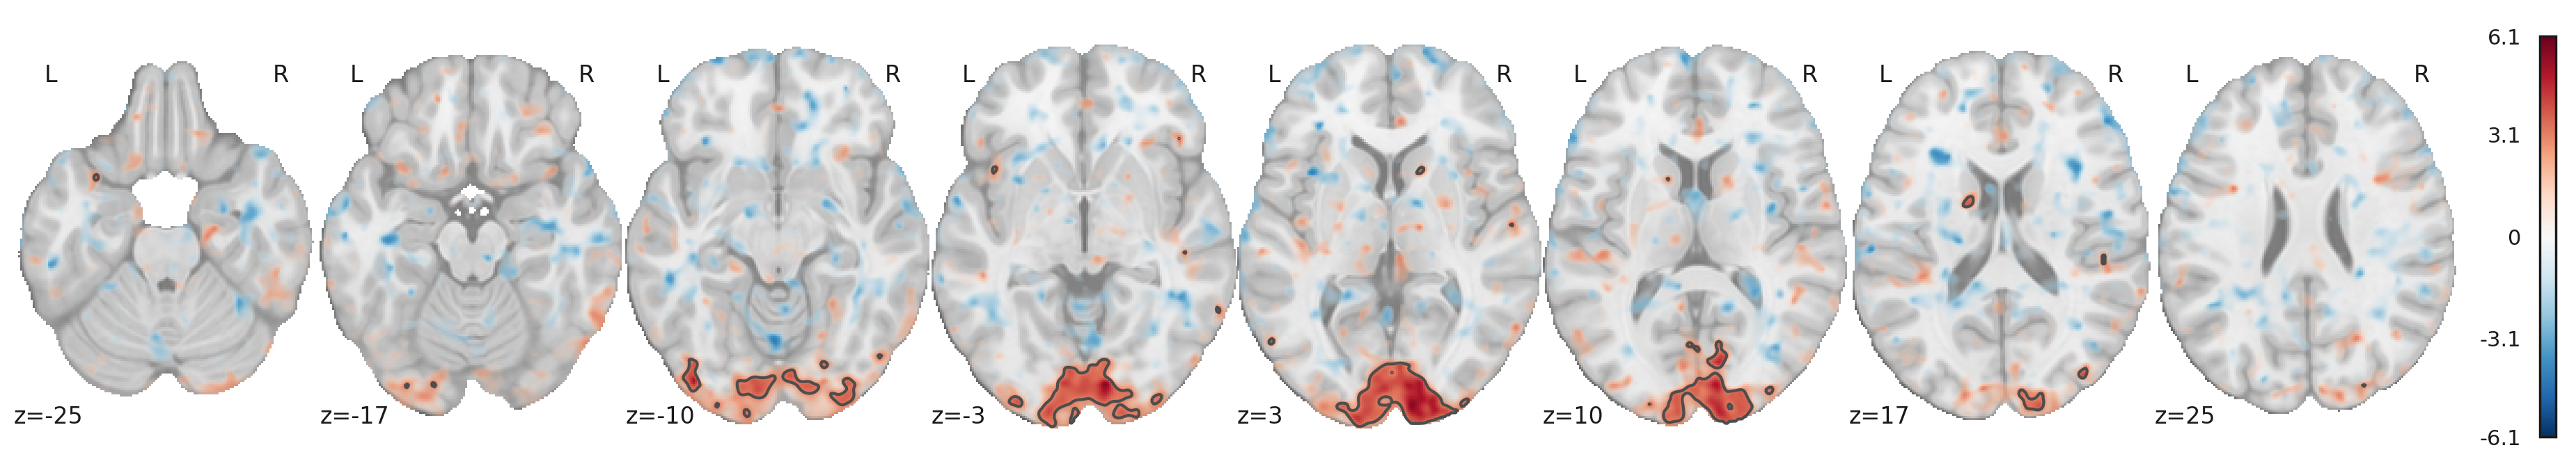

In [104]:
display = plotting.plot_stat_map(
    zstat, 
    bg_img='/roman/erlangen-conn/external-data/mni-icbm2009/mni_icbm152_t1_tal_nlin_asym_09a_brain.nii.gz',
    black_bg=False,
    display_mode='z',
    transparency=zstat,
    transparency_range=[1, threshold],
    cut_coords=np.linspace(-25, 25, 8)
)

display.add_contours(
    zstat, filled=False, levels=[threshold], colors=['.3']
)

In [61]:
zstat.to_filename(ROOT / 'AVERAGES' / 'group-zstat.nii.gz')
zstat_thr.to_filename(ROOT / 'AVERAGES' / 'group-zstat-thr.nii.gz')


---

# Save the data

In [ ]:
# timestamp = datetime.datetime.strftime(datetime.datetime.now(), '%d-%B-%Y_%H-%M')
# filename = f'/RAID1/jupytertmp/quantification/DATA_{timestamp}.joblib'

# joblib.dump(DATA, filename)

filename = ROOT / 'DATA_12April2026-THESIS.joblib'
joblib.dump(DATA, filename)

---

# Diagnostic plots

In [ ]:
DATA = joblib.load('/RAID1/jupytertmp/quantification/DATA_12April2026-THESIS.joblib')

## Feng fit parameters

In [ ]:
fits = np.array([data['feng_fit_popt'] for data in DATA.values()])

In [ ]:
df = (
    pd.DataFrame(fits, columns=['A1', 'l1', 'A2', 'l2', 'A3', 'l3'])
    .assign(subject=subjects)
    .melt(id_vars='subject', var_name='parameter')
)
df = df.assign(cohort=df.apply(lambda x: 'old' if x.subject < 23 else 'new', axis=1))

fig, axs = plt.subplots(1,2, figsize=(8,4), constrained_layout=True)
sns.swarmplot(data=df[df.parameter.str.startswith('A')], x='parameter', y='value', ax=axs[0], hue='cohort', size=5)
sns.swarmplot(data=df[df.parameter.str.startswith('l')], x='parameter', y='value', ax=axs[1], hue='cohort', size=5)

## Feng fits

In [ ]:
fig, axs = plt.subplots(2,1, figsize=(9,8))

tt = np.linspace(0, 5, 10000)
for subject, data in DATA.items():
    feng_blood = data['feng_function']
    feng_plasma = data['feng_plasma_function']
    if subject >= 23:
        color='crimson'
    else:
        color='.2'
    axs[0].plot(tt, feng_blood(tt), color=color, alpha=0.5)
    axs[1].plot(tt, feng_plasma(tt), color=color, alpha=0.5)

axs[0].set(title='Raw blood', ylabel='Bq')
axs[1].set(title='Plasma', ylabel='Bq/mL')

## Calibration factor for blood

In [ ]:
bgs_early = [data['background'] for subject, data in DATA.items() if subject < 23 and subject != 12]
bgs_late = [data['background'] for subject, data in DATA.items() if subject >= 23]

In [ ]:
print(f'The multiplicative calibration factor adjustment for subjects 23 on: {np.mean(bgs_early) / np.mean(bgs_late)}')

In [ ]:
print(f"Multiplicative adjustment factor for subject 12, even though it's not late: {np.mean(bgs_early) / DATA[12]['background']}")

In [ ]:
peaks_early = [ DATA[8]['blood_tac'][int(data['blood_delay'] * 60 + 20)] for subject, data in DATA.items() if subject < 23]
peaks_late = [ DATA[8]['blood_tac'][int(data['blood_delay'] * 60 + 20)] for subject, data in DATA.items() if subject >= 23]

In [ ]:
np.mean(peaks_early) / np.mean(peaks_late)

## Calibration factor for PET

In [ ]:
DATA

In [ ]:
bls_early = np.array([data['regressors']['baseline'] for subject, data in DATA.items() if subject < 23 ])
bls_late = np.array([data['regressors']['baseline'] for subject, data in DATA.items() if subject >= 23 ])

In [ ]:
calibration_pet = bls_early.mean(axis=0) / bls_late.mean(axis=0)

In [ ]:
time.iloc[-1]

In [ ]:
fig, axs = plt.subplots(3,1, figsize=(7,10), sharex=True, constrained_layout=True)

for subject, data in DATA.items():

    time = data['regressors']['time']
    baseline = data['regressors']['baseline']

    if subject < 23:
        c = '0.8'   
        axs[2].semilogy(time, baseline, color=c)
    else:
        c = 'crimson'
        axs[2].semilogy(time, baseline * calibration_pet, color=c)
        # axs[1].text(time.iloc[-1], baseline.iloc[-1], f'{subject}', va='center', ha='left', color='crimson', fontsize=7)
        # axs[2].text(time.iloc[-1], (baseline * calibration_pet).iloc[-1], f'{subject}', va='center', ha='left', color='crimson', fontsize=7)

    axs[1].semilogy(time, baseline, color=c)

axs[0].semilogy(time, calibration_pet, color='0.3')

axs[1].sharey(axs[2])
axs[1].set(title='Raw PET baseline')
axs[2].set(title='Adjusted PET baseline', xlabel='Time [min]', ylabel='Bq/mL')
axs[0].set(ylabel='Calibration factor')

for ax in axs:
    ax.grid(linewidth=0.7, alpha=0.3)

In [ ]:
bl = masking.apply_mask(DATA[8])

## Patlak plot fitting 

In [ ]:
subject = 12
data = DATA[subject]

subroot = ROOT / f'sub-{subject:03}'

pet = data['pet']
mask = data['v1_mask']
plasma_integral = data['plasma_integral']
feng_plasma_fit = data['feng_plasma_function']
glucose = data['glucose']
pet_timing = data['pet_timing']
task_timing = data['task_timing']

timeseries = masking.apply_mask(pet, mask)
voxel_names = np.array([ f'{i}x{j}x{k}' for i, j, k in zip(*nib.load(mask).get_fdata().nonzero()) ]) # voxel count starts from zero

In [ ]:
voxel_coord = '181x117x74'

voxel, = np.where(np.array(voxel_names) == voxel_coord)

fig, ax = plt.subplots(figsize=(9,5))
ax.scatter(pet_timing.time, timeseries[:, voxel], s=1, color='.8', label='data')
ax.fill_between(task_timing.time, ax.get_ylim()[-1], where=task_timing.checker > 0, fc='.5', alpha=0.1, label='checker')
ax.set(xlabel='Time [min]', ylabel='Radioactivity [Bq/mL]', title=f'sub-{subject:03} tasks')

def f(xs, model:LinearRegression):
    return model.intercept_ + xs * model.coef_

for task in ['rest', 'checker']:
    for run in range(1,5):

        # Identify indices for patlak x and y for the run
        nframes = (task_timing[task] == run).sum()
        mid = (nframes+1) // 2
        cumsum = (task_timing[task] == run).cumsum()
        # mid_three = (mid-2 < cumsum) & (cumsum <= mid+1)
        skip_two = cumsum > 2
        frames_mask = skip_two & (task_timing[task] == run) & pet_timing.quantification

        # Patlak x and y
        x_subset = pet_timing.loc[frames_mask, 'time']
        y_subset = timeseries[frames_mask, voxel]
        model = LinearRegression(positive=True, fit_intercept=True).fit(X=x_subset.to_numpy()[:, np.newaxis], y=y_subset)
        ts = [ task_timing[task_timing[task] == run].time.min(), task_timing[task_timing[task] == run].time.max() ]

        ax.scatter(x_subset, y_subset, s=5, color='k')
        ax.plot(ts, f(ts, model), color='crimson', alpha=0.5)

In [ ]:
img = nib.load(data['anat'])
ijk = list(map(int, voxel_coord.split('x')))
xyz = nib.affines.apply_affine(img.affine, ijk)

plotting.plot_img(img, cut_coords=xyz, colorbar=False)

## Masks averages

In [ ]:
# v1_overall = np.median(v1_overall_voxels),
        # m1_overall = np.median(m1_overall_voxels),
        # gm_overall = np.median(gm_overall_voxels),
        # v1_pet_timeseries = masking.apply_mask(pet, mask)
        # gm_pet_timeseries = masking.apply_mask(pet, mask)
        # m1_pet_timeseries = masking.apply_mask(pet, mask)
        # v1_pet_mean = np.median(v1_pet_timeseries.sum(axis=0)),
        # m1_pet_mean = np.median(m1_pet_timeseries.sum(axis=0)),
        # gm_pet_mean = np.median(gm_pet_timeseries.sum(axis=0)),
        # subject = subject,
        # glucose = data['glucose'],
        # hematocrit = data['hematocrit'],
        # blood_delay = data['blood_delay'],
# X = data['pet_timing'].time.to_numpy()[:, np.newaxis]
#     plasma_integral_slope, = LinearRegression().fit(X, data['plasma_integral']).coef_

### Check blood parameters

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(df.hematocrit, df.glucose, marker='o', s=df.blood_delay*200, color='.1')

for i, line in df.iterrows():
    ax.text(line.hematocrit, line.glucose, f'{line.subject:.0f}', va='center', ha='center', color='w', fontsize=7)
ax.set(xlabel='hematocrit', ylabel='glucose', title='Blood: hematocrit vs glucose. Size=blood delay');
ax.axvline(df.hematocrit.mean(), linewidth=1, color='k', alpha=0.2)
ax.axhline(df.glucose.mean(), linewidth=1, color='k', alpha=0.2)

### Check pet mean vs plasma integral

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(df.v1_pet_mean, df.plasma_integral_slope, marker='o', s=200, color='.1')

for i, line in df.iterrows():
    ax.text(line.v1_pet_mean, line.plasma_integral_slope, f'{line.subject:.0f}', va='center', ha='center', color='w', fontsize=7)
ax.set(xlabel='pet mean', ylabel='slope of plasma integral', title='PET vs blood');
ax.axvline(df.v1_pet_mean.mean(), linewidth=1, color='k', alpha=0.2)
ax.axhline(df.plasma_integral_slope.mean(), linewidth=1, color='k', alpha=0.2)

In [ ]:
df = []

for subject, data in DATA.items():

    # our method
    overall = ROOT / f'sub-{subject:03}/final-fixed/cmrglc/sub-fp{subject:03}_quant-cmrglc_task-global.nii.gz'
    rest = ROOT / f'sub-{subject:03}/final-fixed/cmrglc-skiptwo/sub-fp{subject:03}_quant-cmrglc_frames-skiptwo_task-rest_run-average.nii.gz'
    checker = ROOT / f'sub-{subject:03}/final-fixed/cmrglc-skiptwo/sub-fp{subject:03}_quant-cmrglc_frames-skiptwo_task-checker_run-average.nii.gz'
    # glm
    baseline = ROOT / f'sub-{subject:03}/final-fixed/glm/sub-fp{subject:03}_quant-cmrglc_reg-baseline.nii.gz'
    checker_glm = ROOT / f'sub-{subject:03}/final-fixed/glm/sub-fp{subject:03}_quant-cmrglc_reg-checker.nii.gz'
    task = image.math_img('baseline + checker', baseline=baseline, checker=checker_glm)
    
    pet = data['pet']
    gm_probseg = data['gm_probseg']

    mask = data['v1_mask']
    mask = image.math_img('mask * (gm > 0.7)', mask=mask, gm=gm_probseg)
    v1_rest_voxels, v1_checker_voxels, v1_baseline_voxels, v1_task_voxels = masking.apply_mask([rest, checker, baseline, task], mask)

    mask = data['gm_mask_edited']
    mask = image.math_img('mask * (gm > 0.7)', mask=mask, gm=gm_probseg)
    gm_rest_voxels, gm_checker_voxels, gm_baseline_voxels, gm_task_voxels = masking.apply_mask([rest, checker, baseline, task], mask)

    mask = data['sm1_mask']
    mask = image.math_img('mask * (gm > 0.7)', mask=mask, gm=gm_probseg)
    m1_rest_voxels, m1_checker_voxels, m1_baseline_voxels, m1_task_voxels = masking.apply_mask([rest, checker, baseline, task], mask)

    df.append(dict(
        subject = subject,
        v1_ours_rest = np.median(v1_rest_voxels),
        v1_ours_checker = np.median(v1_checker_voxels),
        v1_glm_rest = np.median(v1_baseline_voxels),
        v1_glm_checker = np.median(v1_task_voxels),
        m1_ours_rest = np.median(m1_rest_voxels),
        m1_ours_checker = np.median(m1_checker_voxels),
        m1_glm_rest = np.median(m1_baseline_voxels),
        m1_glm_checker = np.median(m1_task_voxels),
        gm_ours_rest = np.median(gm_rest_voxels),
        gm_ours_checker = np.median(gm_checker_voxels),
        gm_glm_rest = np.median(gm_baseline_voxels),
        gm_glm_checker = np.median(gm_task_voxels),
    ))

    print(subject, end='\r')

df = pd.DataFrame(df)

### Check activation

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(df.v1_rest, df.v1_checker, color='.2', label='V1', s=100)
ax.scatter(df.m1_rest, df.m1_checker, color='.8', label='M1', s=5)
ax.legend(frameon=False)
ax.set(xlabel='rest', ylabel='checker', title='Subjects: rest vs checker', xlim=[20,80], ylim=[20,80])
ax.axline((50,50), slope=1, color='.7', linewidth=1, linestyle=':')
ax.grid(linewidth=1, alpha=0.5)

for i, line in df.iterrows():
    ax.plot([line.v1_rest, line.m1_rest], [line.v1_checker, line.m1_checker], linewidth=1, alpha=0.1, color='k')
    ax.text(line.v1_rest, line.v1_checker, f'{line.subject:.0f}', ha='center', va='center', color='w', fontsize=7)

In [ ]:
df_checker_vs_rest = df.melt(id_vars='subject', var_name='variable', value_name='cmrglc')
cols = df_checker_vs_rest.variable.str.split('_', expand=True)
cols.columns = ['area', 'method', 'condition']
df_checker_vs_rest = pd.concat([df_checker_vs_rest, cols], axis=1)

In [ ]:
df_checker_vs_rest

In [ ]:
df.to_csv)

In [ ]:
fig, axs = plt.subplots(2,1, figsize=(8,8), sharey=True, sharex=True, constrained_layout=True)
sns.violinplot(data=df_checker_vs_rest.loc[df_checker_vs_rest.method=='ours'], x='area', y='cmrglc', hue='condition', ax=axs[0], alpha=0.8, linewidth=0, inner_kws=dict(box_width=5, whis_width=1))
sns.violinplot(data=df_checker_vs_rest.loc[df_checker_vs_rest.method=='glm'], x='area', y='cmrglc', hue='condition', ax=axs[1], alpha=0.8, linewidth=0, inner_kws=dict(box_width=5, whis_width=1))

for ax in axs:
    ax.grid(linewidth=1, alpha=0.5, axis='y')
    ax.legend(frameon=False)
    for spine in ax.spines:
        ax.spines[spine].set_visible(False)
    ax.tick_params(length=0)
axs[0].set(title='Our method')
axs[1].set(title='GLM', xticklabels=['V1', 'M1', 'GM'])

In [ ]:
import pingouin

pingouin.rm_anova(
    data=df_checker_vs_rest.loc[(df_checker_vs_rest.method=='glm') & (df_checker_vs_rest.area.isin(['v1', 'm1']))], 
    dv='cmrglc', 
    within=['condition', 'area'], 
    subject='subject', 
    detailed=True
)

In [ ]:
posthocs = pingouin.pairwise_tests(
    data=df_checker_vs_rest.loc[(df_checker_vs_rest.method=='glm') & (df_checker_vs_rest.area.isin(['v1', 'm1']))], 
    dv='cmrglc',
    within=['area', 'condition'],
    subject='subject',
    padjust='bonf',
    interaction=True,
)

posthocs.round(5)

In [ ]:
df_checker_vs_rest.to_csv(ROOT / 'checker-vs-rest.csv', index=False)

In [ ]:
df.to_csv(ROOT / 'checker-vs-rest-wide.csv', index=False)

In [ ]:
ROOT

## Global CMRGlc: V1 mask vs GM except occipital 

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(df.v1_overall, df.gm_overall, marker='o', s=150, color='.1')

for i, line in df.iterrows():
    ax.text(line.v1_overall, line.gm_overall, f'{line.subject:.0f}', va='center', ha='center', color='w', fontsize=8)
ax.set(xlabel='cmrglc V1', ylabel='cmrglc GM', title='Subjects: V1 vs GM global cmrglc', xlim=[20,50], ylim=[20,50])
ax.grid(linewidth=1, alpha=0.5)
ax.axline((0,0), slope=1, color='.7', linewidth=1)

## Time series

In [ ]:
for subject, data in DATA.items():

    subroot = ROOT / f'sub-{subject:03}'

    task_timing = data['task_timing']
    pet = data['pet']
    mask = data['v1_mask']

    timeseries = masking.apply_mask(pet, mask)
    ts = timeseries.mean(axis=1)

    fig, ax = plt.subplots(figsize=(9,5))
    ax.scatter(task_timing.time, ts, s=5, color='.3')
    ax.fill_between(task_timing.time, ax.get_ylim()[-1], where=task_timing.checker > 0, fc='crimson', alpha=0.1, label='checker')
    ax.set(xlabel='Time [min]', ylabel='Radioactivity [Bq]', title=f'sub-{subject:03} V1 average')
    ax.legend(frameon=False)
    fig.savefig(subroot / 'final/cmrglc' / f'sub-{subject:03}_V1-plot.png', dpi=300)

    feng_plasma = data['feng_plasma_function']
    min, max = pet_timing.time.iloc[[0,-1]]
    time_highres = np.linspace(min, max, 1000)

    fig, ax = plt.subplots(figsize=(9,5))
    ax.plot(time_highres, feng_plasma(time_highres), color='k', alpha=0.3, label='fit')
    ax.scatter(pet_timing.time, feng_plasma(pet_timing.time.to_numpy()), s=5, color='crimson', label='sampled')
    ax.set(xlabel='Time [min]', ylabel='Radioactivity [Bq]', title=f'sub-{subject:03} Feng plasma fit')
    ax.legend(frameon=False)
    fig.savefig(subroot / 'final/cmrglc' / f'sub-{subject:03}_Feng-plasma.png', dpi=300)

    blood = data['blood_tac']
    time = data['time']
    feng = data['feng_function']
    fig, ax = plt.subplots(figsize=(9,5))
    ax.scatter(time, blood, s=1, color='.3', alpha=0.2, label='data')
    ax.plot(time_highres, feng(time_highres), color='k', alpha=0.8, linewidth=1, label='fit')
    ax.scatter(pet_timing.time, feng(pet_timing.time.to_numpy()), s=5, color='crimson', label='sampled')
    ax.set(xlabel='Time [min]', ylabel='Radioactivity [Bq/mL]', title=f'sub-{subject:03} Feng whole blood fit')
    ax.legend(frameon=False)
    fig.savefig(subroot / 'final/cmrglc' / f'sub-{subject:03}_Feng-blood.png', dpi=300)

## GLM

In [ ]:
df_glm = []

for subject, data in DATA.items():

    baseline = ROOT / f'sub-{subject:03}/final-fixed/glm/sub-fp{subject:03}_quant-cmrglc_reg-baseline.nii.gz'
    checker = ROOT / f'sub-{subject:03}/final-fixed/glm/sub-fp{subject:03}_quant-cmrglc_reg-checker.nii.gz'

    task = image.math_img('baseline + checker', baseline=baseline, checker=checker)
    
    mask = data['v1_mask']
    v1_bl_voxels, v1_task_voxels = masking.apply_mask([baseline, task], mask)

    mask = data['gm_mask_edited']
    gm_bl_voxels, gm_task_voxels = masking.apply_mask([baseline, task], mask)

    df_glm.append(dict(
        subject = subject,
        v1_baseline = np.median(v1_bl_voxels),
        v1_task = np.median(v1_task_voxels),
        gm_baseline = np.median(gm_bl_voxels),
        gm_task = np.median(gm_task_voxels),
    ))
    print(subject, end='\r')

df_glm = pd.DataFrame(df_glm)

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(df_glm.v1_baseline, df_glm.v1_task, color='.2', label='V1', s=100)
ax.scatter(df_glm.gm_baseline, df_glm.gm_task, color='.8', label='GM except Occ', s=5)
ax.legend(frameon=False)
ax.set(xlabel='baseline', ylabel='baseline + checker', title='Subjects: GLM baseline vs checker', xlim=[20,60], ylim=[20,60])
ax.axline((50,50), slope=1, color='.7', linewidth=1, linestyle=':')
ax.grid(linewidth=1, alpha=0.5)

for i, line in df_glm.iterrows():
    ax.plot([line.v1_baseline, line.gm_baseline], [line.v1_task, line.gm_task], linewidth=1, alpha=0.1, color='k')
    ax.text(line.v1_baseline, line.v1_task, f'{line.subject:.0f}', ha='center', va='center', color='w', fontsize=7)

---

In [ ]:
print(
    ' -add '.join([f'sub-{subject:03}/glm-v2/sub-fp{subject:03}_quant-beta_reg-checker_space-mni.nii.gz' for subject in subjects])
    )

In [ ]:
len(subjects)

# Compare ours and GLM
## $\Delta CMR_{Glc}$

In [ ]:
df = []

for subject, data in DATA.items():

    print(subject, end='\r')

    v1_mask = f'/RAID1/jupytertmp/quantification/sub-{subject:03}/transforms/sub-fp{subject:03}_mask-v1_space-pet.nii.gz'
    rest_file = f'/RAID1/jupytertmp/quantification/sub-{subject:03}/final/cmrglc/sub-fp{subject:03}_quant-cmrglc_frames-mid3_task-rest_run-average.nii.gz'
    checker_file = f'/RAID1/jupytertmp/quantification/sub-{subject:03}/final/cmrglc/sub-fp{subject:03}_quant-cmrglc_frames-mid3_task-checker_run-average.nii.gz'
    
    baseline_file = f'/RAID1/jupytertmp/quantification/sub-{subject:03}/final/glm/sub-fp{subject:03}_quant-cmrglc_reg-baseline.nii.gz'
    task_file = f'/RAID1/jupytertmp/quantification/sub-{subject:03}/final/glm/sub-fp{subject:03}_quant-cmrglc_reg-checker.nii.gz'
    
    delta_cmrglc = image.math_img('checker - rest', checker=checker_file, rest=rest_file)
    task_cmrglc = image.math_img('baseline + task', baseline=baseline_file, task=task_file)

    results = masking.apply_mask([rest_file, checker_file, baseline_file, task_cmrglc, task_file, delta_cmrglc], v1_mask)
    names = ['rest_blocks', 'checker_blocks', 'rest_glm', 'checker_glm', 'delta_blocks', 'delta_glm']

    for name, result in zip(names, results):
        df.append( (f'sub-{subject:03}', *name.split('_'), result.mean()) )

df = pd.DataFrame(df, columns=['subject', 'calc', 'method', 'value'])

In [ ]:
df[df.calc=='delta']

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
ax = sns.violinplot(data=df[df.calc=='delta'], x='method', y='value', alpha=0.7, linewidth=0, inner_kws=dict(box_width=8, whis_width=1, linewidth=1), ax=ax)
ax.set(xlabel='Method', ylabel=r'$\Delta CMR_{Glc}$');

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.violinplot(data=df[df.calc != 'delta'], x='method', y='value', hue='calc', alpha=0.7, linewidth=0, inner_kws=dict(box_width=8, whis_width=1, linewidth=1), ax=ax)
ax.set(xlabel='Method', ylabel=r'$CMR_{Glc}$');

In [ ]:
import pingouin as pg

In [ ]:
df[df.calc == 'delta']

In [ ]:
fig, ax = plt.subplots(figsize=(9,7))
pg.plot_blandaltman(df.loc[(df.calc == 'delta') & (df.method == 'blocks'), 'value'], df.loc[(df.calc == 'delta') & (df.method == 'glm'), 'value'])

In [ ]:
x1 = np.random.normal(loc=0, scale=1, size=1000)
x2 = np.random.normal(loc=0.2, scale=1, size=1000)



In [ ]:
print(stats.ttest_1samp(x1, 0))
linear_model = LinearRegression()#.fit(x1[:, np.newaxis], np.zeros_like(x1))

In [ ]:
linear_model.coef_ / stats.sem(linear_model.coef_)

In [ ]:
linear_model.predict(x1)